# Percobaan Pengaruh Jumlah Layer Konvolusi

#### Import Dataset

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

Seeding

In [2]:
import random
import os

# Atur seed
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

#### Load Dataset

In [3]:
# Load dataset CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Split train -> 40k train, 10k validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# Normalisasi data (0-1)
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Train shape: {x_train.shape}, Validation shape: {x_val.shape}, Test shape: {x_test.shape}")

Train shape: (40000, 32, 32, 3), Validation shape: (10000, 32, 32, 3), Test shape: (10000, 32, 32, 3)


## Model 1: 1 Layer Konvolusi

c:\Users\agilf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3828 - loss: 1.7123 - val_accuracy: 0.5665 - val_loss: 1.2580
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5684 - loss: 1.2344 - val_accuracy: 0.6022 - val_loss: 1.1560
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6158 - loss: 1.1061 - val_accuracy: 0.6184 - val_loss: 1.1090
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6500 - loss: 1.0128 - val_accuracy: 0.6259 - val_loss: 1.0941
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6806 - loss: 0.9307 - val_accuracy: 0.6243 - val_loss: 1.1103
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7056 - loss: 0.8587 - val_accuracy: 0.6202 - val_loss: 1.1382
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7277 - loss: 0.7955 - val_accuracy: 0.6216 - val_loss: 1.1439
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7488 - loss: 0.7411 - val_accu

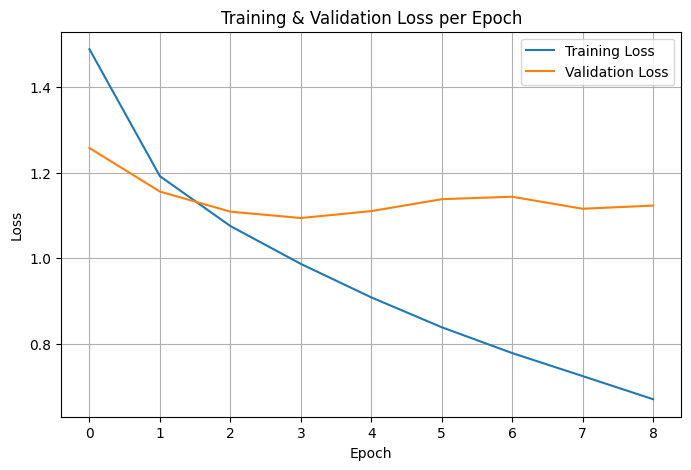

In [4]:
# Make model with 1 convolutional layer
model1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model1
model1.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callback
early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Training model1
history = model1.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Prediksi di test set
y_pred_probs = model1.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung macro F1-Score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score di Test Set: {f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 2: 2 Layer Konvolusi

c:\Users\agilf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3523 - loss: 1.7811 - val_accuracy: 0.5375 - val_loss: 1.3168
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5526 - loss: 1.2707 - val_accuracy: 0.6016 - val_loss: 1.1448
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6082 - loss: 1.1223 - val_accuracy: 0.6304 - val_loss: 1.0717
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6475 - loss: 1.0199 - val_accuracy: 0.6438 - val_loss: 1.0297
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6734 - loss: 0.9435 - val_accuracy: 0.6520 - val_loss: 1.0059
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6963 - loss: 0.8797 - val_accuracy: 0.6541 - val_loss: 0.9995
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7158 - loss: 0.8272 - val_accuracy: 0.6619 - val_loss: 1.0003
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7327 - loss: 0.7757 - val_accu

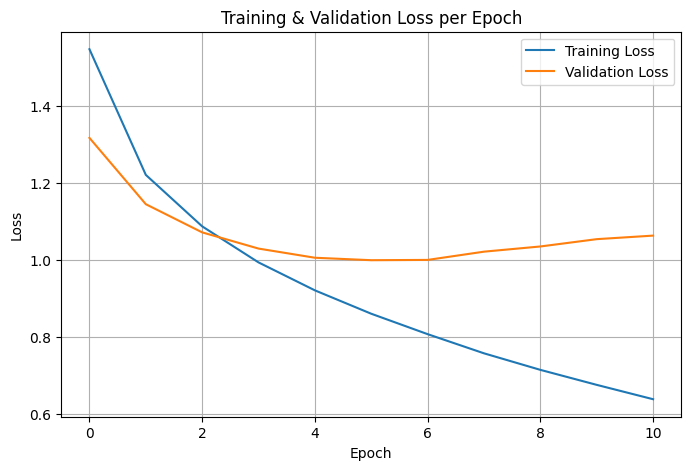

In [5]:
# Make model with 2 convolutional layer
model2 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model2
model2.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callback
early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Training model2
history = model2.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Prediksi di test set
y_pred_probs = model2.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung macro F1-Score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score di Test Set: {f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 3: 3 Layer Konvolusi

c:\Users\agilf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2720 - loss: 1.9528 - val_accuracy: 0.4711 - val_loss: 1.4684
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4736 - loss: 1.4530 - val_accuracy: 0.5366 - val_loss: 1.3101
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5324 - loss: 1.3042 - val_accuracy: 0.5644 - val_loss: 1.2395
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5660 - loss: 1.2167 - val_accuracy: 0.5852 - val_loss: 1.1874
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5906 - loss: 1.1533 - val_accuracy: 0.6004 - val_loss: 1.1540
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6145 - loss: 1.0972 - val_accuracy: 0.6035 - val_loss: 1.1561
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6304 - loss: 1.0504 - val_accuracy: 0.6157 - val_loss: 1.1163
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6469 - loss: 1.0068 - val_accu

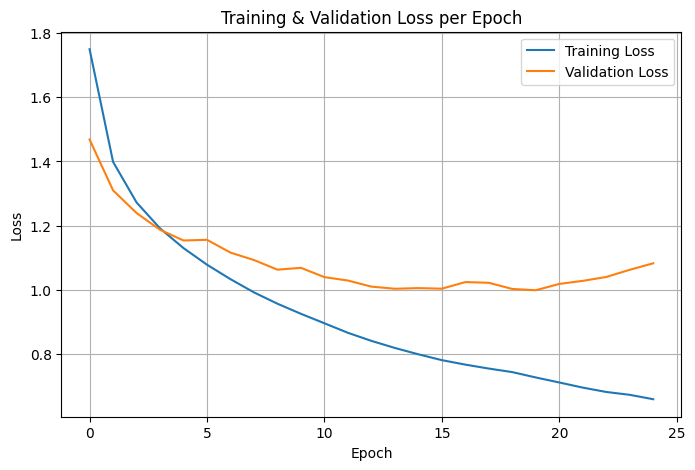

In [6]:
# Make model with 3 convolutional layer
model3 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model3
model3.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callback
early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Training model3
history = model3.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Prediksi di test set
y_pred_probs = model3.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung macro F1-Score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score di Test Set: {f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()